In [2]:
from IPython.display import display, HTML
display(HTML("<h2>Agentic AI System</h2> \n " \
"<h3> Simple AI ChatBot"))

In [3]:
from typing import Annotated, List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [4]:
class State(TypedDict):

    messages: Annotated[List, add_messages]




In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BFA328B4D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BFA34A4050>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# llm = init_chat_model("groq: llama3-8b-8192")
# llm

In [8]:
def ChatBot(state : State):

    return {
        "messages" : [llm.invoke(state["messages"])]
    }

In [9]:
graph_builder = StateGraph(State)

graph_builder.add_node("LLMChatNode", ChatBot)

graph_builder.add_edge(START, "LLMChatNode")
graph_builder.add_edge("LLMChatNode", END)

graph= graph_builder.compile()


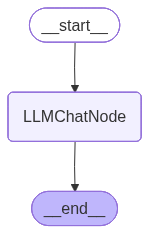

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [11]:
result = graph.invoke({"messages": "Hi, How Can I Assist You?"})

for msg in result["messages"]:
    msg.pretty_print()



================================ Human Message =================================

Hi, How Can I Assist You?
================================== Ai Message ==================================

Hello. I'm happy to help you with any questions or topics you'd like to discuss. I'm a large language model, so I can provide information, answer questions, generate text, or even help with creative writing tasks.

If you're not sure where to start, I can offer some suggestions:

1. Ask me a question on a specific topic, such as science, history, or technology.
2. Get help with a language-related task, such as grammar, vocabulary, or translation.
3. Generate ideas for a creative writing project, such as a story or a poem.
4. Discuss a current event or news topic.
5. Play a game, such as trivia or word games.

What sounds interesting to you?


In [12]:
result["messages"]

[HumanMessage(content='Hi, How Can I Assist You?', additional_kwargs={}, response_metadata={}, id='bc2cb8aa-6cf1-448f-9df5-117108f0811d'),
 AIMessage(content="Hello. I'm happy to help you with any questions or topics you'd like to discuss. I'm a large language model, so I can provide information, answer questions, generate text, or even help with creative writing tasks.\n\nIf you're not sure where to start, I can offer some suggestions:\n\n1. Ask me a question on a specific topic, such as science, history, or technology.\n2. Get help with a language-related task, such as grammar, vocabulary, or translation.\n3. Generate ideas for a creative writing project, such as a story or a poem.\n4. Discuss a current event or news topic.\n5. Play a game, such as trivia or word games.\n\nWhat sounds interesting to you?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 43, 'total_tokens': 191, 'completion_time': 0.296141564, 'completion_tokens_deta

In [13]:
result["messages"][-1].content

"Hello. I'm happy to help you with any questions or topics you'd like to discuss. I'm a large language model, so I can provide information, answer questions, generate text, or even help with creative writing tasks.\n\nIf you're not sure where to start, I can offer some suggestions:\n\n1. Ask me a question on a specific topic, such as science, history, or technology.\n2. Get help with a language-related task, such as grammar, vocabulary, or translation.\n3. Generate ideas for a creative writing project, such as a story or a poem.\n4. Discuss a current event or news topic.\n5. Play a game, such as trivia or word games.\n\nWhat sounds interesting to you?"

In [14]:
for event in graph.stream({"messages": "How Are You?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here and ready to help with any questions or tasks you may have. What's on your mind today?


## ChatBot with Tavily

In [15]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_result =2)

tool.invoke("What is LangGraph?")


{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [17]:
def multiPly(a:int, b:int)->int:
    """
    Multipy a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: Output int
    
    """

In [18]:
tools = [tool, multiPly]

In [19]:
llm_with_tool = llm.bind_tools(tools)


In [20]:
llm_with_tool


_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BFA328B4D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BFA34A4050>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when 